In [3]:
import pandas as pd

# produção (mensal, uma tabela por categoria)
categorias = ["bovinos", "suinos", "frangos", "ovos", "leite"]
producao = {}
for cat in categorias:
    df = pd.read_csv(f"../documentos/tratados/{cat}_tidy.csv")
    producao[cat] = df.pivot_table(index="data", columns="variavel", values="valor")

# preços (mensal)
precos = pd.read_csv("../documentos/tratados/precos_tidy.csv")
precos_wide = precos.pivot_table(index="data", columns="variavel", values="valor")

# sindirações (anual, granularidade diferente — fica separado por enquanto)
sindiracoes = pd.read_csv("../documentos/tratados/sindiracoes_modelo.csv")

# exemplo: base do bovino já com preços de mercado juntados
base_bovinos = producao["bovinos"].join(precos_wide, how="left")
base_bovinos.index = pd.to_datetime(base_bovinos.index)
print(base_bovinos.tail())

variavel    Animais abatidos  Peso total das carcaças  preco_milho  \
data                                                                 
2026-02-01         3243012.0              825318738.0        67.86   
2026-03-01         3626763.0              922853400.0        70.90   
2026-04-01         3473610.0              884996418.0        67.95   
2026-05-01         3588664.0              924791645.0        65.60   
2026-06-01         3659069.0              948281593.0        63.68   

variavel    preco_soja_parana  preco_sorgo_estimado  
data                                                 
2026-02-01             120.10                 57.68  
2026-03-01             122.44                 60.27  
2026-04-01             121.35                 57.76  
2026-05-01             123.03                 55.76  
2026-06-01             125.22                 54.13  


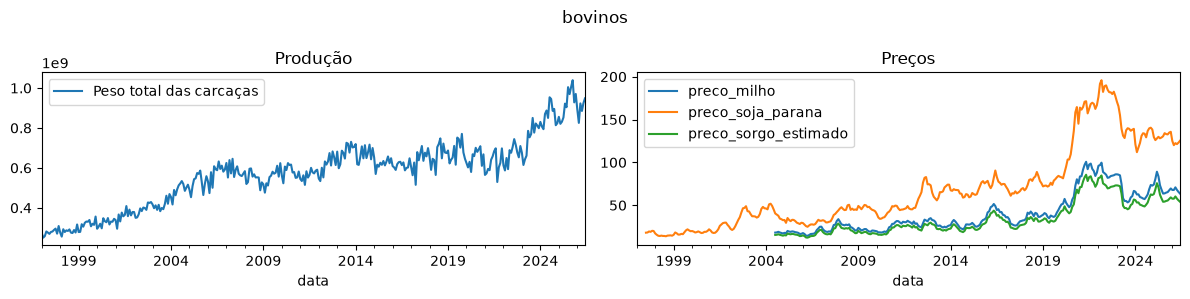

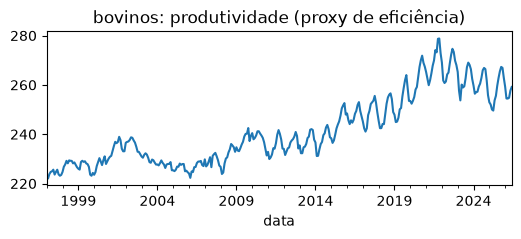

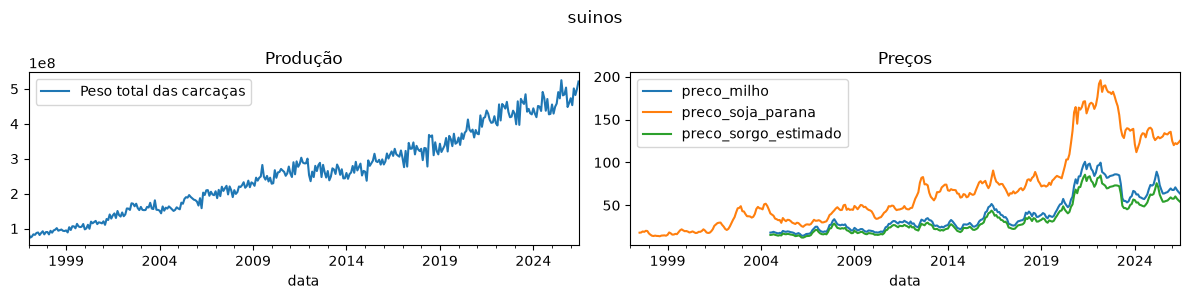

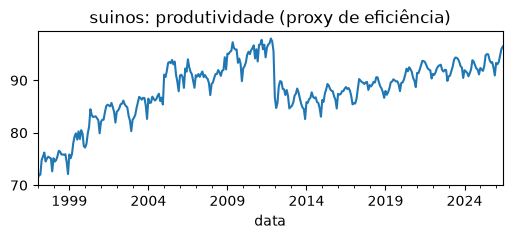

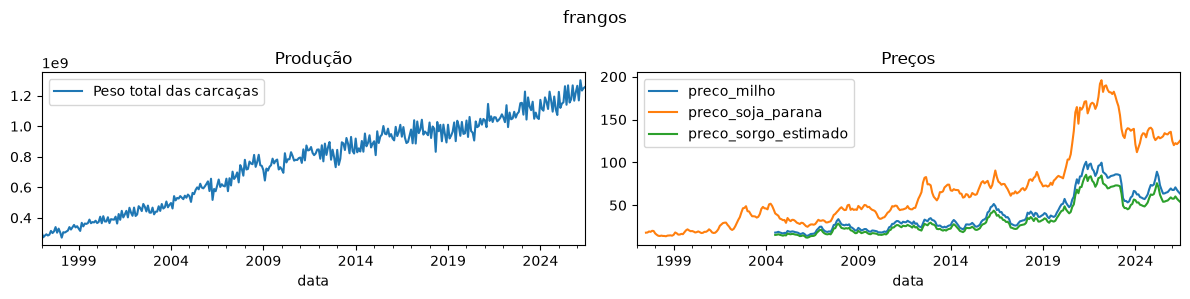

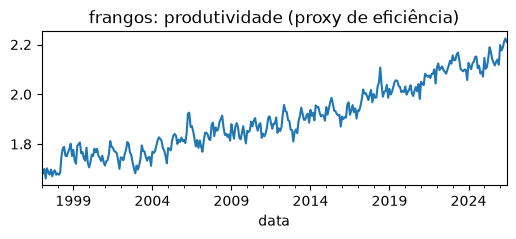

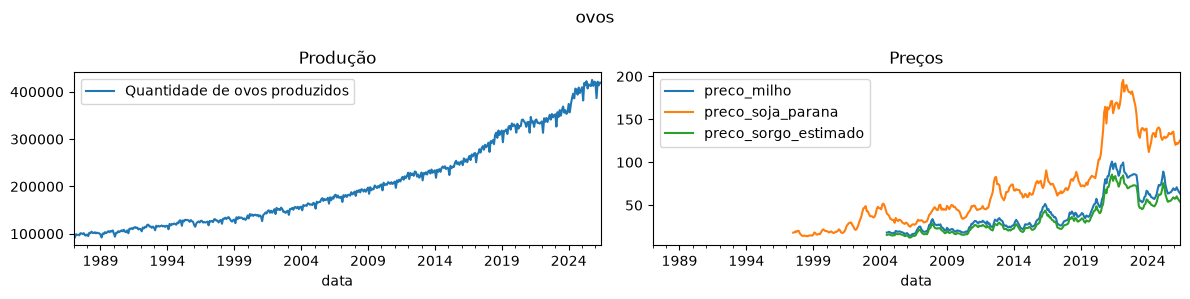

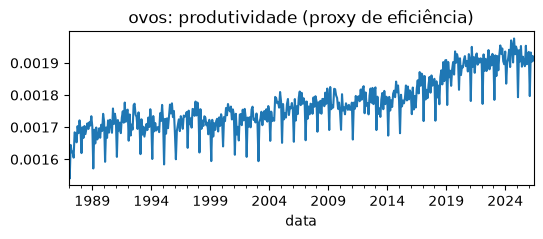

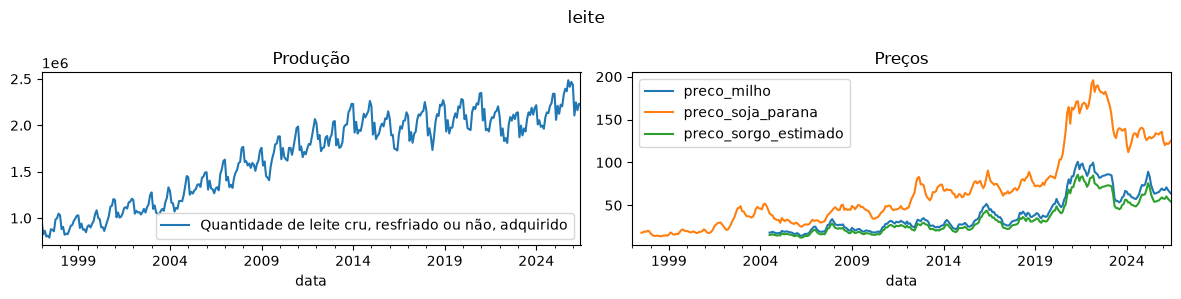

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

CATEGORIAS = ["bovinos", "suinos", "frangos", "ovos", "leite"]

# pares (numerador, denominador) para calcular uma métrica de produtividade,
# quando a categoria tiver as duas variáveis. Ajuste os nomes se vierem diferentes.
RAZAO = {
    "bovinos": ("Peso total das carcaças", "Animais abatidos"),
    "suinos": ("Peso total das carcaças", "Animais abatidos"),
    "frangos": ("Peso total das carcaças", "Animais abatidos"),
    "ovos": ("Quantidade de ovos produzidos", "Número de cabeças de galinhas poedeiras nos estabelecimentos agropecuários"),
    "leite": None,  # não tem contagem de cabeças nessa tabela
}

for cat in CATEGORIAS:
    base = pd.read_csv(f"../documentos/tratados/bases_unificadas/base_{cat}.csv", index_col="data", parse_dates=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(cat)

    col_producao = [c for c in base.columns if "quantidade" in c.lower() or "peso total" in c.lower()]
    base[col_producao].plot(ax=axes[0], legend=True)
    axes[0].set_title("Produção")

    col_precos = [c for c in base.columns if c.startswith("preco_")]
    base[col_precos].plot(ax=axes[1], legend=True)
    axes[1].set_title("Preços")

    plt.tight_layout()
    plt.show()

    if RAZAO[cat]:
        num, den = RAZAO[cat]
        if num in base.columns and den in base.columns:
            razao = (base[num] / base[den]).rename(f"{cat}_produtividade")
            razao.plot(figsize=(6, 2), title=f"{cat}: produtividade (proxy de eficiência)")
            plt.show()